# I. Introduction

The relationship between a price of an instrument versus time elapsed can be measured fundamentally as
$$
price_t = \beta_1 + \beta_0 + \epsilon_t
$$

In reality, markets are rarely always trending to the point where we use techniques such as regression to find the best fit line.

## Experiments with different regressions

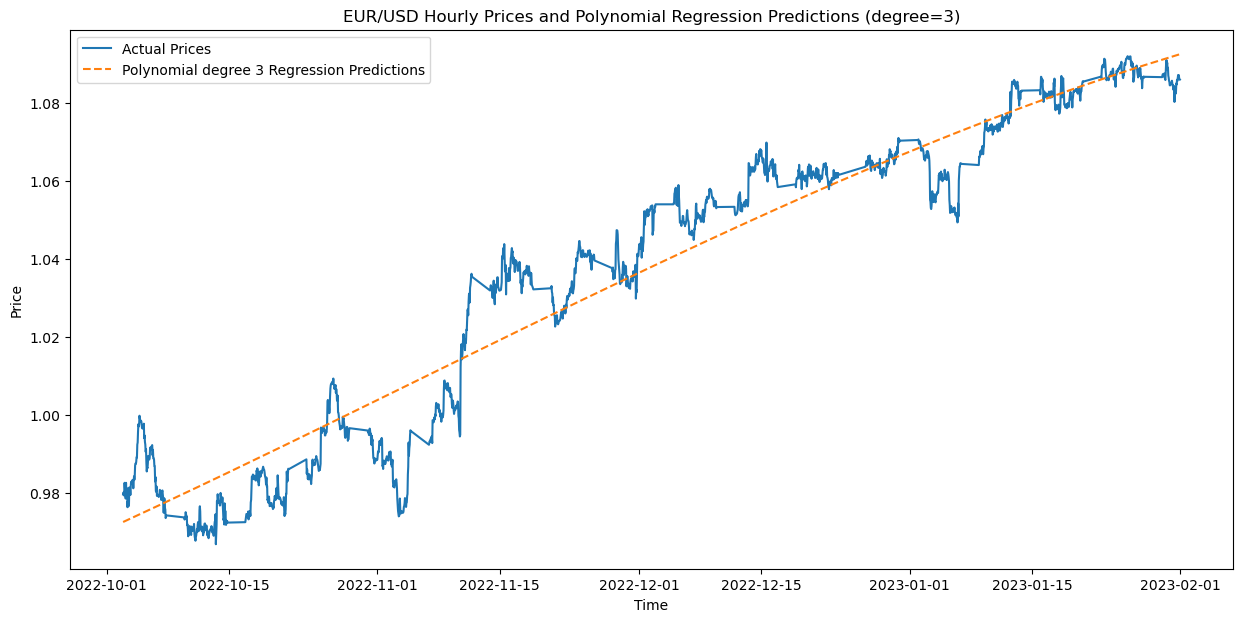

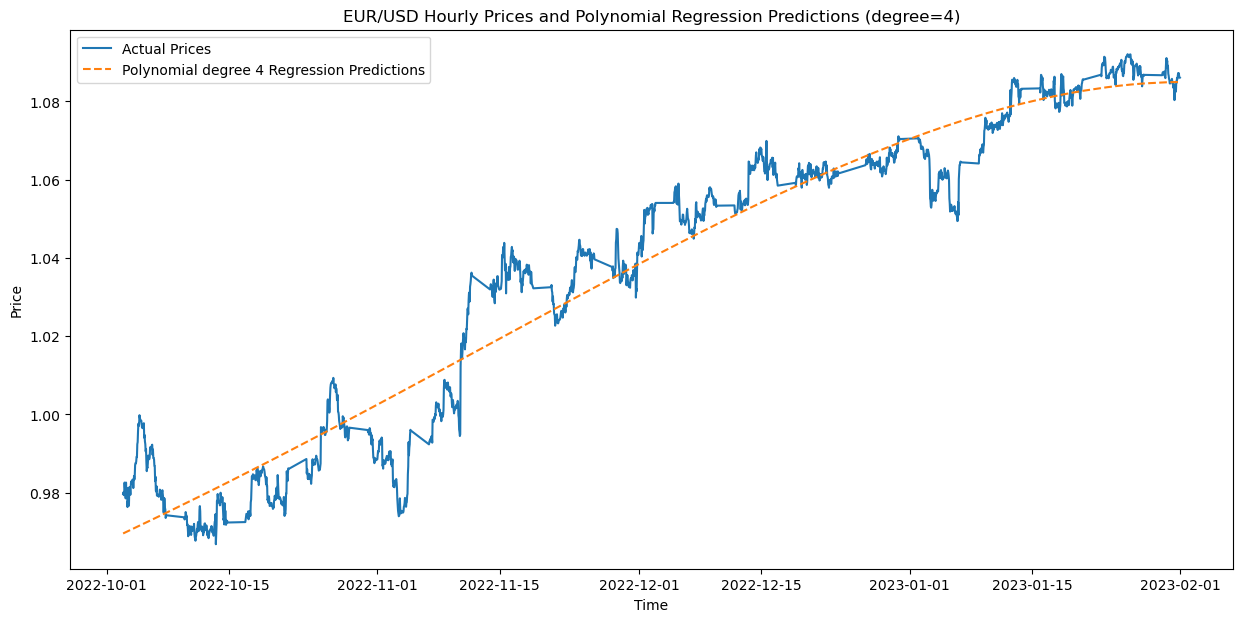

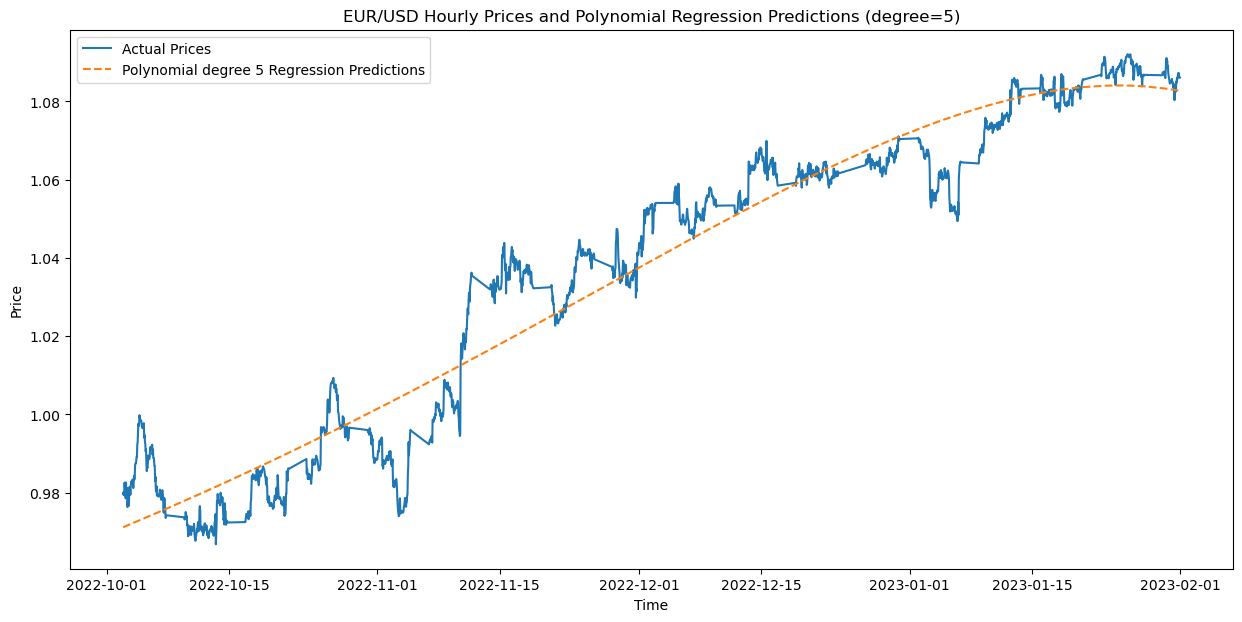

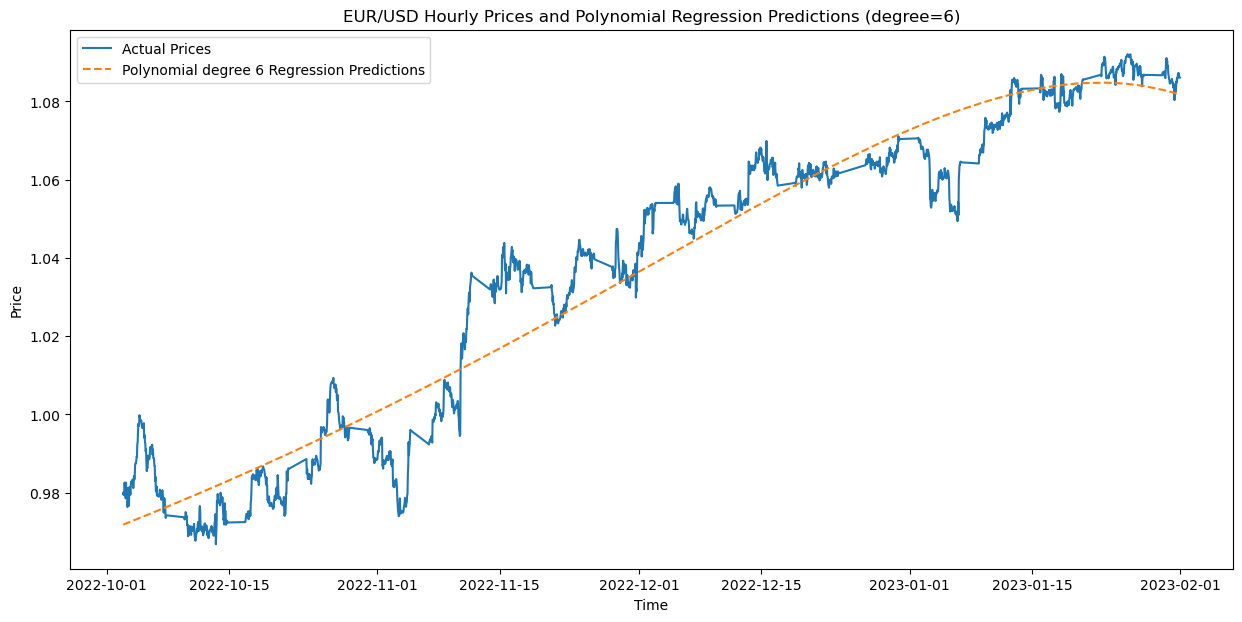

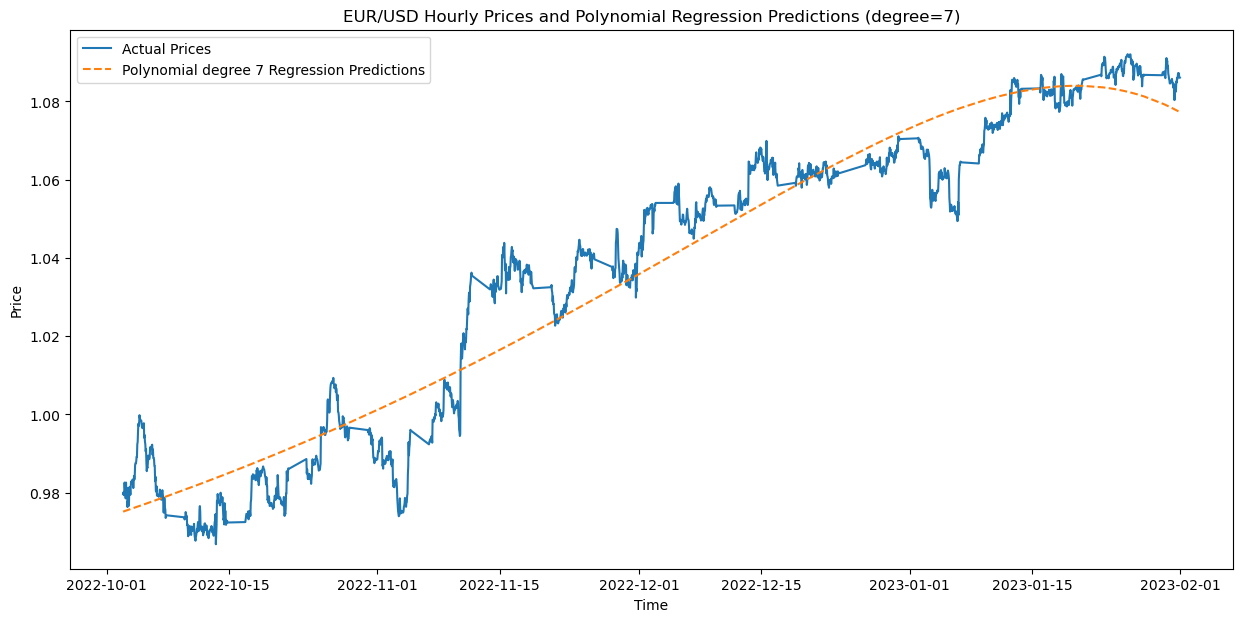

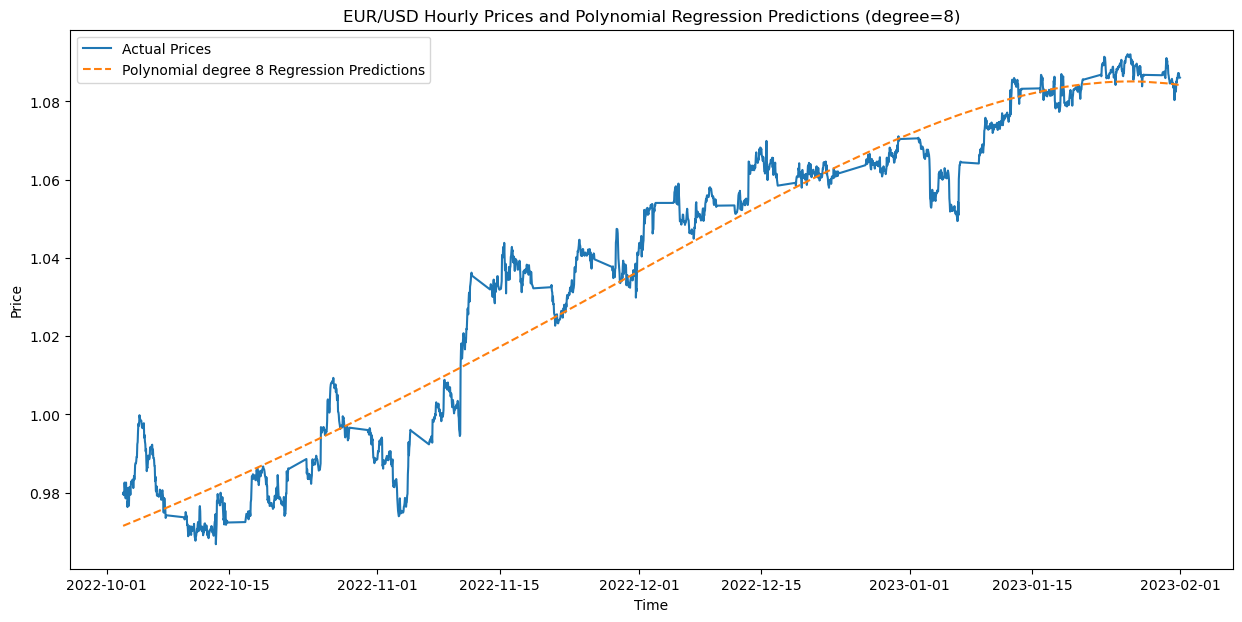


## Polynomial Regression Performance

| Degree | Mean Squared Error | R-squared Score |
|--------|--------------------|-----------------|
| 3 | 0.000105 | 0.928940 |
| 4 | 0.000097 | 0.934848 |
| 5 | 0.000100 | 0.932463 |
| 6 | 0.000105 | 0.929077 |
| 7 | 0.000112 | 0.924554 |
| 8 | 0.000102 | 0.931219 |


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
from IPython.display import Markdown, display

# Load the data
data = pd.read_csv('../data/raw/eur_usd_trending.csv', index_col='time', parse_dates=True)


data['time'] = (data.index - data.index[0]).total_seconds()
X = data[['time']].values
y = data['close'].values


degrees = [3, 4, 5, 6, 7, 8]

results = []

for degree in degrees:
    poly = PolynomialFeatures(degree)
    X_poly = poly.fit_transform(X)
    
    model = make_pipeline(StandardScaler(), SGDRegressor(max_iter=1000, tol=1e-3))
    
    model.fit(X_poly, y)
    
    y_pred = model.predict(X_poly)
    
    # Calculate metrics
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    
    # Store results
    results.append((degree, mse, r2))
    
    # Plot the results
    plt.figure(figsize=(15, 7))
    plt.plot(data.index, y, label='Actual Prices')
    plt.plot(data.index, y_pred, label=f'Polynomial degree {degree} Regression Predictions', linestyle='--')
    plt.xlabel('Time')
    plt.ylabel('Price')
    plt.title(f'EUR/USD Hourly Prices and Polynomial Regression Predictions (degree={degree})')
    plt.legend()
    plt.show()

# Create markdown table
markdown_str = """
## Polynomial Regression Performance

| Degree | Mean Squared Error | R-squared Score |
|--------|--------------------|-----------------|
"""

for degree, mse, r2 in results:
    markdown_str += f"| {degree} | {mse:.6f} | {r2:.6f} |\n"

display(Markdown(markdown_str))


A simple polynomial regression suggests that for the dataset above, 4 and 5 return the best r2 and mse scores. However, just from glancing at the data I can see that the model fails to capture the pattern of EUR/USD prices. This tells us that using time as the only predictor wouldn't give an accurate representation on price.

## Introducing other predictors

$$
\text{Price}_t = \alpha + \beta_1 \cdot \text{Time}_t + \beta_2 \cdot \text{Lagged Price}_{t-1} + \beta_3 \cdot \text{News}_t +  \epsilon_t+$$


These three simple predictors allow us to perform some feature engineering.

This project deals with finding the optimal combination of predictors, adjusting their weights and training models to accurately predict the direction and price of any tradable instrument. For this case study, we will solely be focusing on the EUR/USD foreign exchange data. The EURUSD was chosen for the extent of its econometrics and volatility. 